# Import libraries and data

In [1]:
import os
import glob

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import griddata
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

In [2]:
era5_path = "/work5/ERA5_daily_landgrid_only/global/compressed_sfc_fc_daily_198001.nc4"
tw_metrics_file = "/work10/archive/CMIP6/CMIP-SSPs/thirstwave_metrics_growing_season.nc"

OUT_DIR = "."
FRAMES_DIR = os.path.join(OUT_DIR, "frames_thirstwave_gif")
GIF_PATH = os.path.join(OUT_DIR, "Figure1_left_animated.gif")

FRAME_DPI = 150
FRAME_DURATION_MS = 500  # 0.5 s per year

os.makedirs(FRAMES_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Plotting functions

In [3]:
# =========================================================
# Read lat/lon from ERA5 reference file
# =========================================================
era5_path = "/work5/ERA5_daily_landgrid_only/global/compressed_sfc_fc_daily_198001.nc4"
ds_era5 = xr.open_dataset(era5_path)
lat_1d = ds_era5["lat"].values
lon_1d = ds_era5["lon"].values

res = 0.25
lon_reg = np.arange(lon_1d.min(), lon_1d.max() + res, res)
lat_reg = np.arange(lat_1d.min(), lat_1d.max() + res, res)
LON, LAT = np.meshgrid(lon_reg, lat_reg)

# ============================================================
#  regrid helper
# ============================================================
def regrid_to_regular(values_1d):
    valid = np.isfinite(lon_1d) & np.isfinite(lat_1d) & np.isfinite(values_1d)
    grid = griddata(
        points=(lon_1d[valid], lat_1d[valid]),
        values=values_1d[valid],
        xi=(LON, LAT),
        method="nearest"
    )
    return grid

# ============================================================
#  plotting helper
# ============================================================
def make_land_mask_from_points(lon_1d, lat_1d, lon_reg, lat_reg):
    land_mask = np.full((len(lat_reg), len(lon_reg)), False, dtype=bool)
    ix = np.round((lon_1d - lon_reg[0]) / (lon_reg[1] - lon_reg[0])).astype(int)
    iy = np.round((lat_1d - lat_reg[0]) / (lat_reg[1] - lat_reg[0])).astype(int)
    valid = (
        (ix >= 0) & (ix < len(lon_reg)) &
        (iy >= 0) & (iy < len(lat_reg)) &
        np.isfinite(lon_1d) & np.isfinite(lat_1d)
    )
    land_mask[iy[valid], ix[valid]] = True
    return land_mask
def make_sig_points_by_fraction(
    lon_1d, lat_1d, p_1d, value_1d,
    threshold=0.05, grid_deg=4.0, frac_thresh=0.3
):
    valid = (
        np.isfinite(lon_1d) & np.isfinite(lat_1d) &
        np.isfinite(p_1d) & np.isfinite(value_1d)
    )
    if np.sum(valid) == 0:
        return np.array([]), np.array([])
    lon_v   = lon_1d[valid]; lat_v = lat_1d[valid]; p_v = p_1d[valid]
    lon_bin = np.floor((lon_v + 180.0) / grid_deg).astype(int)
    lat_bin = np.floor((lat_v +  90.0) / grid_deg).astype(int)
    box_id  = lon_bin.astype(str) + "_" + lat_bin.astype(str)
    keep_lon, keep_lat = [], []
    for box in np.unique(box_id):
        idx      = np.where(box_id == box)[0]
        frac_sig = np.sum(p_v[idx] < threshold) / len(idx)
        if frac_sig >= frac_thresh:
            keep_lon.append((lon_bin[idx[0]] + 0.5) * grid_deg - 180.0)
            keep_lat.append((lat_bin[idx[0]] + 0.5) * grid_deg -  90.0)
    return np.array(keep_lon), np.array(keep_lat)

def filter_sig_points_with_landmask(
    sig_lon, sig_lat, land_mask, lon_reg, lat_reg,
    half_window=2, min_land_frac=0.2
):
    if len(sig_lon) == 0:
        return np.array([]), np.array([])
    ny, nx = land_mask.shape
    keep_lon, keep_lat = [], []
    for x, y in zip(sig_lon, sig_lat):
        ix = np.argmin(np.abs(lon_reg - x))
        iy = np.argmin(np.abs(lat_reg - y))
        x0 = max(ix-2, 0); x1 = min(ix+3, nx)
        y0 = max(iy-2, 0); y1 = min(iy+3, ny)
        if np.mean(land_mask[y0:y1, x0:x1]) >= min_land_frac:
            keep_lon.append(x); keep_lat.append(y)
    return np.array(keep_lon), np.array(keep_lat)

land_mask = make_land_mask_from_points(lon_1d, lat_1d, lon_reg, lat_reg)
def plot_panel(ax, values_1d, sig_lon, sig_lat, title,
               vmin, vmax, cmap, extend="both", label=""):
    plot_grid = values_1d
    im = ax.pcolormesh(
        LON, LAT, plot_grid,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax
    )

    if len(sig_lon) > 0:
        ax.scatter(sig_lon, sig_lat, s=5, c="k",
                   transform=ccrs.PlateCarree(), zorder=5)

    ax.set_extent([-180, 180, -65, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, color="0.9", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="gray")
    ax.coastlines(linewidth=1.5)
    ax.text(
        0.02, 1.05, label,
        transform=ax.transAxes,
        fontsize=30,
        fontweight='bold',
        va='top',
        ha='left'
    )
    # ========================================================
    # inset colorbar
    # ========================================================
    cax = inset_axes(
        ax,
        width="35%",
        height="3%",
        loc='lower center',
        bbox_to_anchor=(0.15, 0.1, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cb = plt.colorbar(
        im,
        cax=cax,
        orientation="horizontal",
        extend=extend
    )
    
    if (vmax - vmin) < 2.0001:
        cb.set_ticks(np.arange(vmin, np.floor(vmax)+.5, .5))
    else:
        cb.set_ticks(np.arange(vmin, np.floor(vmax)+1, 1))
    cb.ax.tick_params(labelsize=16)
    cb.ax.xaxis.set_label_position('top')
    cb.ax.xaxis.set_ticks_position('bottom')
    cb.outline.set_linewidth(1)
    cb.outline.set_edgecolor("black")
    cax.patch.set_alpha(0.8)

    ax.set_title(title, fontsize=20)
    
    # ========================================================
    # inset histogram (area-weighted, same data as map)
    # ========================================================
    lat2d = LAT if np.ndim(LAT) == 2 else np.repeat(LAT[:, None], plot_grid.shape[1], axis=1)
    weights = np.cos(np.deg2rad(lat2d))
    valid_mask = (
        np.isfinite(plot_grid) &
        np.isfinite(weights) &
        land_mask
    )    
    valid_data = plot_grid[valid_mask].ravel()
    valid_weights = weights[valid_mask].ravel()
    
    if len(valid_data) > 0:
        global_mean = np.sum(valid_data * valid_weights) / np.sum(valid_weights)
        global_std = np.sqrt(
            np.sum(valid_weights * (valid_data - global_mean)**2) / np.sum(valid_weights)
        )
    
        # clip only for histogram/colorbar consistency
        hist_data = np.clip(valid_data, vmin, vmax)
        hist_weights = valid_weights / np.sum(valid_weights)
    
        inset_ax = inset_axes(
            ax,
            width="12%",
            height="15%",
            loc="lower left",
            bbox_to_anchor=(0.1, 0.155, 1.1, 1.3),
            bbox_transform=ax.transAxes
        )
    
        bins = np.linspace(vmin, vmax, 22)
    
        hist_vals, bin_edges, patches = inset_ax.hist(
            hist_data,
            bins=bins,
            weights=hist_weights,
            density=False,
            edgecolor="black",
            linewidth=1.2
        )
    
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
        for patch, center in zip(patches, bin_centers):
            patch.set_facecolor(cmap(norm(center)))
    
        inset_ax.tick_params(labelsize=14)
        inset_ax.get_yaxis().set_visible(False)

        for spine in inset_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("gray")
            spine.set_alpha(0.5)

        inset_ax.set_xlim(vmin, vmax)
        xticks = np.linspace(vmin, vmax, 3)  # 左、中、右
        inset_ax.set_xticks(xticks)
        formatted_mean = f"{global_mean:.3f}".replace("-", "−")
        formatted_std = f"{global_std:.3f}".replace("-", "−")
        inset_ax.set_facecolor("0.9")
        inset_ax.set_title(
            f"μ = {formatted_mean}\nσ = {formatted_std}",
            fontsize=16,
            ha="left",
            x=0
        )
        xtick_labels = [
            f"{vmin:.1f}",
            f"{xticks[1]:.1f}",
            f">{vmax:.1f}"
        ]
        inset_ax.set_xticklabels(xtick_labels)
    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    return im

Custom colormap:

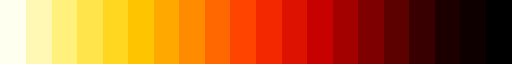

In [4]:
cmap20 = LinearSegmentedColormap.from_list(
    "fire_fast_dark",
    [
        "#fffff0",
        "#ffef66",
        "#ffcc00",
        "#ff8800",
        "#ff3300",
        "#cc0000",
        "#770000",
        "#220000",
        "#000000",
    ],
    N=20
)
cmap20

# Main loop

In [5]:
# Load data one year at a time
tw_feature = xr.open_dataset(tw_metrics_file)
intensity_all = tw_feature["intensity"].values.astype(np.float32)     # (n_years, n_points)
frequency_all = tw_feature["event_count"].values.astype(np.float32)   # (n_years, n_points)
duration_all = tw_feature["mean_duration"].values                     # (n_years, n_points)
years = tw_feature.year.values
n_years = len(years)
print(f"Got {n_years} years of data: {years[0]} - {years[-1]}")

Got 43 years of data: 1981 - 2023


In [6]:
# Source - https://stackoverflow.com/a/9031848
# Posted by astrofrog, modified by community. See post 'Timeline' for change history
# Retrieved 2026-09-09, License - CC BY-SA 4.0
import warnings
warnings.filterwarnings(action='ignore')


# Build one frame per year, reusing plot_panel
frame_paths = []

for y_idx, year in enumerate(years):
    intensity = regrid_to_regular(intensity_all[y_idx])
    frequency = regrid_to_regular(frequency_all[y_idx])
    duration = regrid_to_regular(duration_all[y_idx])

    fig, axes = plt.subplots(
        3, 1,
        figsize=(9, 25 * 3 / 5),
        subplot_kw={"projection": ccrs.Robinson()}
    )
    axes = axes.flatten()

    plot_panel(
        axes[1],
        intensity, np.array([]), np.array([]),
        r"Intensity [mm day$^{-1}$]",
        vmin=0, vmax=2,
        cmap=cmap20,
        extend="max",
        label="E."
    )

    plot_panel(
        axes[0],
        frequency, np.array([]), np.array([]),
        r"Frequency [event year$^{-1}$]",
        vmin=0, vmax=5,
        cmap=cmap20,
        extend="max",
        label="C."
    )

    plot_panel(
        axes[2],
        duration, np.array([]), np.array([]),
        r"Duration [days event$^{-1}$]",
        vmin=3, vmax=5,
        cmap=cmap20,
        extend="max",
        label="G."
    )

    fig.suptitle(str(int(year)), fontsize=28, fontweight="bold", y=1.0)

    plt.tight_layout()

    frame_path = os.path.join(FRAMES_DIR, f"frame_{y_idx:02d}_{int(year)}.png")
    fig.savefig(frame_path, dpi=FRAME_DPI, bbox_inches="tight", pad_inches=0.3)
    plt.close(fig)

    frame_paths.append(frame_path)
    print(f"Frame for {int(year)} saved at {frame_path}")

print("All frames complete!")

Frame for 1981 saved at ./frames_thirstwave_gif/frame_00_1981.png
Frame for 1982 saved at ./frames_thirstwave_gif/frame_01_1982.png
Frame for 1983 saved at ./frames_thirstwave_gif/frame_02_1983.png
Frame for 1984 saved at ./frames_thirstwave_gif/frame_03_1984.png
Frame for 1985 saved at ./frames_thirstwave_gif/frame_04_1985.png
Frame for 1986 saved at ./frames_thirstwave_gif/frame_05_1986.png
Frame for 1987 saved at ./frames_thirstwave_gif/frame_06_1987.png
Frame for 1988 saved at ./frames_thirstwave_gif/frame_07_1988.png
Frame for 1989 saved at ./frames_thirstwave_gif/frame_08_1989.png
Frame for 1990 saved at ./frames_thirstwave_gif/frame_09_1990.png
Frame for 1991 saved at ./frames_thirstwave_gif/frame_10_1991.png
Frame for 1992 saved at ./frames_thirstwave_gif/frame_11_1992.png
Frame for 1993 saved at ./frames_thirstwave_gif/frame_12_1993.png
Frame for 1994 saved at ./frames_thirstwave_gif/frame_13_1994.png
Frame for 1995 saved at ./frames_thirstwave_gif/frame_14_1995.png
Frame for 

In [7]:
# Stitch frames into an animated GIF, 0.5 s per year
frame_paths = sorted(frame_paths, key=lambda p: p)  # already in year order, but be safe
images = [Image.open(p).convert("RGB") for p in frame_paths]

images[0].save(
    GIF_PATH,
    save_all=True,
    append_images=images[1:],
    duration=FRAME_DURATION_MS,
    loop=0,
    optimize=True,
)

print(f"GIF written to {GIF_PATH} ({len(images)} frames, {FRAME_DURATION_MS} ms/frame)")

GIF written to ./Figure1_left_animated.gif (43 frames, 500 ms/frame)
